# **1. Perkenalan Dataset**


### **Deskripsi Dataset:**
Proyek ini menggunakan *Credit Scoring Dataset for Creditworthiness Prediction* yang diperoleh dari platform Kaggle. Dataset ini berisi 12.000 catatan sintetis yang dirancang untuk merepresentasikan riwayat keuangan individu, sehingga sangat relevan untuk tugas penilaian risiko kredit (credit risk assessment).
https://www.kaggle.com/datasets/junaid512/credit-scoring-dataset-creditworthiness-prediction

### **Tujuan Penggunaan:**
Dataset ini dipilih karena memiliki struktur yang rapi (terstruktur dalam format CSV) dan mencakup berbagai variabel penjelas yang komprehensif, mulai dari data demografis, indikator keuangan, hingga pola perilaku kredit. Tujuan utama dari pembangunan model ini adalah untuk mengklasifikasikan kelayakan kredit seseorang (*Creditworthiness*) dengan label target biner (1 untuk *Good* dan 0 untuk *Bad*), yang akan membantu dalam pengambilan keputusan otomatis terkait persetujuan pinjaman.

### **Ringkasan Atribut:**
Data ini terdiri dari 14 kolom yang dikategorikan sebagai berikut:

- Demografis: `Age`, `Gender`, `Education`, `Marital_Status`.
- Indikator Keuangan: `Income`, `Debt`, `Credit_Score`, `Loan_Amount`, `Loan_Term`.
- Perilaku Kredit: `Num_Credit_Cards`, `Payment_History`, `Employment_Status`, `Residence_Type`.
- Variabel Target: `Creditworthiness` (sebagai label klasifikasi).

Dataset ini sangat ideal untuk eksperimen MLOps karena ukurannya yang efisien untuk proses *pipeline* otomatis, namun memiliki kompleksitas fitur yang cukup untuk menerapkan teknik *feature engineering* dan *hyperparameter tuning* dalam alur kerja kita.

# **2. Import Library**

Pada tahap ini, kita akan mengimpor pustaka (*library*) Python yang esensial untuk mendukung alur kerja *Machine Learning Operations* (*MLOps)*. Pustaka yang digunakan mencakup kebutuhan untuk manipulasi data, visualisasi, pemodelan statistik, hingga alat integrasi untuk pelacakan eksperimen dan manajemen model. Penggunaan pustaka ini memastikan bahwa seluruh tahapan eksperimen, mulai dari pemrosesan data hingga pelacakan metrik, dapat terdokumentasi dengan baik, konsisten, dan memenuhi standar *reproducibility* dalam pengembangan sistem machine learning.

In [1]:
# Import library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# Import library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk modeling dan preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

!pip install mlflow==2.19.0 scikit-learn pandas matplotlib seaborn dagshub

# Import library untuk MLOps dan Tracking
import mlflow
import mlflow.sklearn

# Mengatur gaya visualisasi agar lebih menarik
sns.set(style="whitegrid")

# Konfirmasi library berhasil diimpor
print("Library berhasil diimpor!")

Library berhasil diimpor!


# **3. Memuat Dataset**

Tahap ini bertujuan untuk memuat data mentah (data.csv) ke dalam lingkungan pemrograman untuk diproses lebih lanjut. Proses ini melibatkan pembacaan file menggunakan pustaka pandas, kemudian melakukan inspeksi awal untuk memverifikasi struktur data, tipe data, serta memastikan integritas informasi yang akan diolah dalam eksperimen machine learning ini. Dengan memuat dataset secara benar di awal, kita dapat mendeteksi potensi anomali sejak dini, seperti ketidaksesuaian format kolom atau data yang korup.

In [3]:
# Langkah 1: Memuat dataset
df = pd.read_csv('data.csv')

# Langkah 2: Inspeksi struktur data
print("--- 5 Baris Pertama Dataset ---")
print(df.head())

# Langkah 3: Informasi ringkas mengenai dataset
print("\n--- Ringkasan Informasi Dataset ---")
print(df.info())

# Langkah 4: Cek data kosong
print("\n--- Pengecekan Missing Values ---")
print(df.isnull().sum())

--- 5 Baris Pertama Dataset ---
   Age  Gender    Education  Income   Debt  Credit_Score  Loan_Amount  \
0   56  Female       Master  149406  34089           581        49200   
1   69  Female  High School   78896   8626           648        20147   
2   46  Female       Master  119339  46281           329        41307   
3   32    Male  High School  131067  29403           816        19019   
4   60    Male          PhD   38001  30032           673        16317   

   Loan_Term  Num_Credit_Cards Payment_History Employment_Status  \
0         60                 4             Bad        Unemployed   
1         24                 7            Good          Employed   
2         12                 8             Bad        Unemployed   
3         60                 8             Bad          Employed   
4         36                 4         Average          Employed   

  Residence_Type Marital_Status  Creditworthiness  
0         Rented         Single                 1  
1      Mortgaged

# **4. Exploratory Data Analysis (EDA)**

Tahap ini bertujuan untuk menggali karakteristik, pola, dan hubungan antar variabel dalam dataset `data.csv`. EDA memungkinkan kita untuk memahami distribusi fitur, mendeteksi potensi outlier, serta mengidentifikasi korelasi antara fitur-fitur independen dengan variabel target (`Creditworthiness`). Wawasan yang diperoleh dari tahap ini akan menjadi dasar penentuan strategi preprocessing, seperti kebutuhan akan normalisasi, penanganan *outlier*, atau seleksi fitur, yang krusial untuk meningkatkan performa model nantinya.


--- Statistik Deskriptif ---


,Age,Income,Debt,Credit_Score,Loan_Amount,Loan_Term,Num_Credit_Cards,Creditworthiness
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,43.489250,85222.009417,25354.673250,573.967583,25113.951250,35.943000,4.985833,0.702583
std,14.908982,37640.043409,14087.390846,157.816052,14247.092051,16.965162,2.593458,0.457140
min,18.000000,20026.000000,1001.000000,300.000000,501.000000,12.000000,1.000000,0.000000
25%,31.000000,52400.750000,13161.000000,437.000000,12725.000000,24.000000,3.000000,0.000000
50%,43.000000,85756.000000,25382.500000,574.000000,25220.500000,36.000000,5.000000,1.000000
75%,56.000000,117754.750000,37497.500000,709.000000,37348.000000,48.000000,7.000000,1.000000
max,69.000000,149984.000000,49995.000000,849.000000,49996.000000,60.000000,9.000000,1.000000


/tmp/ipykernel_1537/490411529.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Creditworthiness', data=df, palette='viridis')


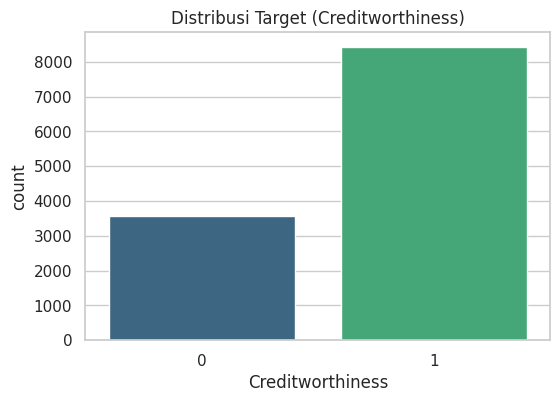

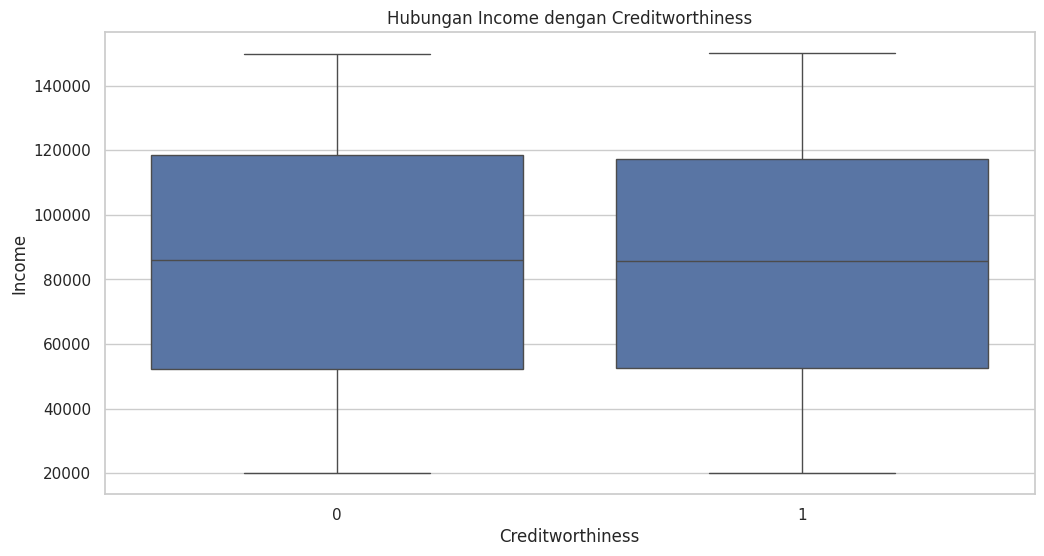

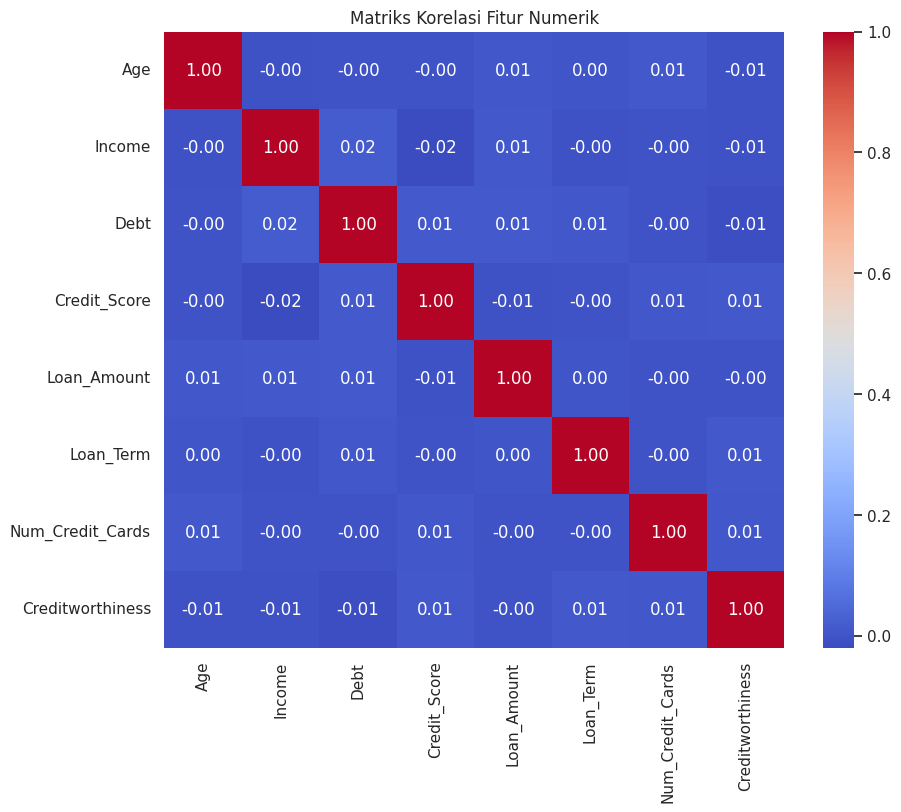

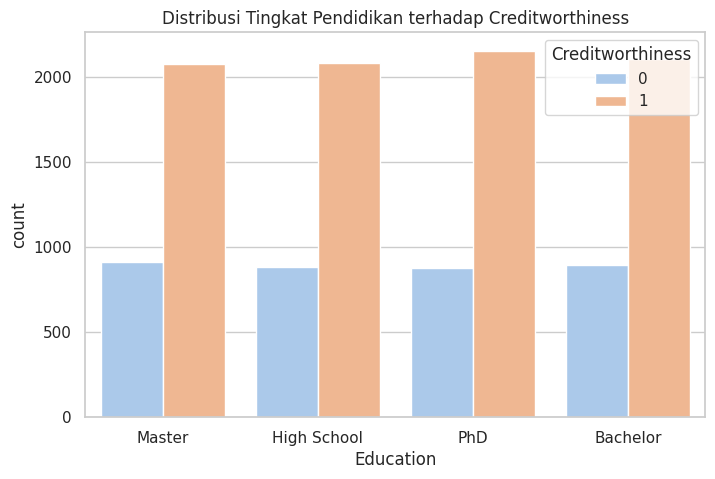

In [4]:
# 1. Melihat statistik deskriptif untuk fitur numerik
print("--- Statistik Deskriptif ---")
display(df.describe())

# 2. Visualisasi distribusi variabel target
plt.figure(figsize=(6, 4))
sns.countplot(x='Creditworthiness', data=df, palette='viridis')
plt.title('Distribusi Target (Creditworthiness)')
plt.show()

# 3. Visualisasi hubungan fitur numerik dengan target
# Menggunakan boxplot untuk melihat perbedaan distribusi fitur berdasarkan target
plt.figure(figsize=(12, 6))
sns.boxplot(x='Creditworthiness', y='Income', data=df)
plt.title('Hubungan Income dengan Creditworthiness')
plt.show()

# 4. Korelasi antar fitur numerik
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()

# 5. Visualisasi fitur kategorikal (Contoh: Education)
plt.figure(figsize=(8, 5))
sns.countplot(x='Education', hue='Creditworthiness', data=df, palette='pastel')
plt.title('Distribusi Tingkat Pendidikan terhadap Creditworthiness')
plt.show()

# **5. Data Preprocessing**

Tahap ini bertujuan untuk menstandarisasi fitur dan mengubah data kategorikal menjadi numerik, sehingga model dapat melakukan inferensi dengan akurat. Mengingat dataset kita sudah bersih dari nilai kosong (*missing values*), fokus kita adalah pada *Encoding* (mengubah teks menjadi angka), Standarisasi (menyamakan skala fitur numerik), dan Pembersihan (menghapus duplikasi). Langkah ini krusial agar model tidak bias terhadap fitur dengan nilai yang sangat besar atau sangat kecil.

In [5]:
# 1. Menghapus data duplikat jika ada
df = df.drop_duplicates()

# 2. Encoding data kategorikal (Label Encoding)
le = LabelEncoder()
cat_cols = ['Gender', 'Education', 'Payment_History', 'Employment_Status', 'Residence_Type', 'Marital_Status']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# 3. Normalisasi/Standarisasi fitur numerik
scaler = StandardScaler()
num_cols = ['Age', 'Income', 'Debt', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Num_Credit_Cards']
df[num_cols] = scaler.fit_transform(df[num_cols])

# 4. Memisahkan fitur (X) dan target (y)
X = df.drop('Creditworthiness', axis=1)
y = df['Creditworthiness']

# 5. Membagi dataset menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Simpan data yang sudah diproses untuk kriteria selanjutnya
X_train.to_csv('X_train_processed.csv', index=False)
X_test.to_csv('X_test_processed.csv', index=False)
y_train.to_csv('y_train_processed.csv', index=False)
y_test.to_csv('y_test_processed.csv', index=False)

print("Preprocessing selesai! Data tersimpan.")

Preprocessing selesai! Data tersimpan.


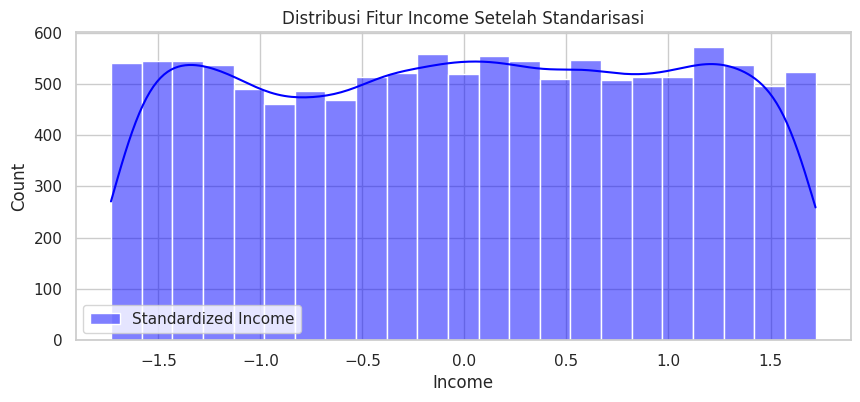

--- 5 Baris Pertama Data Setelah Encoding ---


,Age,Gender,Education,Income,Debt,Credit_Score,Loan_Amount,Loan_Term,Num_Credit_Cards,Payment_History,Employment_Status,Residence_Type,Marital_Status
0,0.839177,0,2,1.705276,0.620036,0.044563,1.690664,1.418083,-0.380139,1,2,2,2
1,1.711171,0,1,-0.168073,-1.187542,0.469125,-0.348644,-0.704001,0.776666,2,0,0,1
2,0.168412,0,2,0.906439,1.485527,-1.552300,1.136634,-1.411363,1.162267,1,2,1,2
3,-0.770658,1,1,1.218035,0.287384,1.533700,-0.427821,1.418083,1.162267,1,0,1,2
4,1.107483,1,3,-1.254594,0.332036,0.627544,-0.617482,0.003360,-0.380139,0,0,2,1


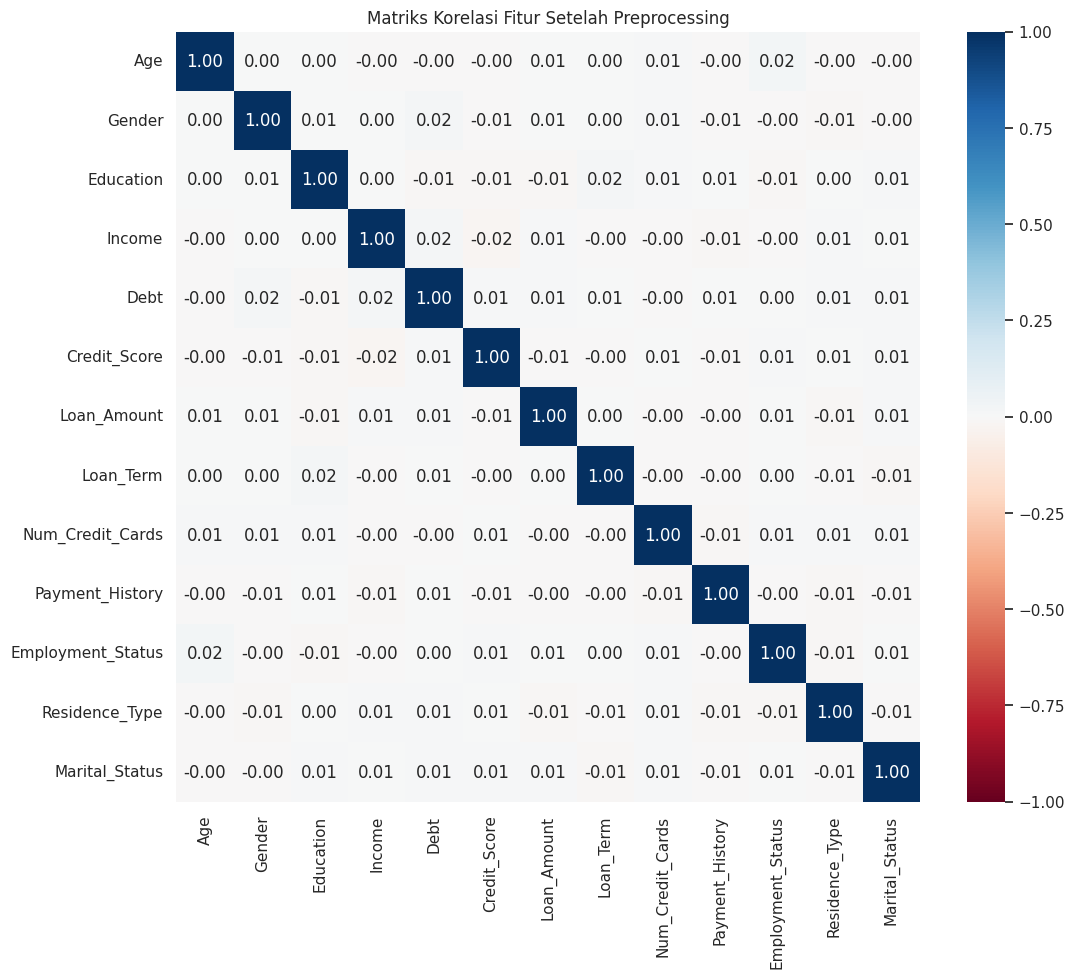


--- Tipe Data Setelah Preprocessing ---
Age                  float64
Gender                 int64
Education              int64
Income               float64
Debt                 float64
Credit_Score         float64
Loan_Amount          float64
Loan_Term            float64
Num_Credit_Cards     float64
Payment_History        int64
Employment_Status      int64
Residence_Type         int64
Marital_Status         int64
dtype: object


In [6]:
# 1. Visualisasi perbandingan distribusi fitur numerik (Sebelum vs Sesudah Scaling)
# Kita ambil contoh fitur 'Income' untuk melihat perubahan skalanya
plt.figure(figsize=(10, 4))

# Sebelum melakukan proses di Tahap 5, Anda seharusnya memiliki dataframe asli (df_raw)
# Jika tidak, Anda bisa melihat distribusi data yang sudah terskala (mean ~ 0, std ~ 1)
sns.histplot(X['Income'], kde=True, color='blue', label='Standardized Income')
plt.title('Distribusi Fitur Income Setelah Standarisasi')
plt.legend()
plt.show()

# 2. Visualisasi struktur data setelah Encoding
# Kita melihat 5 baris pertama untuk memastikan tidak ada lagi tipe data 'object'
print("--- 5 Baris Pertama Data Setelah Encoding ---")
display(X.head())

# 3. Visualisasi heatmap korelasi baru setelah Preprocessing
# Untuk memastikan hubungan antar variabel tetap terjaga
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur Setelah Preprocessing')
plt.show()

# 4. Validasi Tipe Data
print("\n--- Tipe Data Setelah Preprocessing ---")
print(X.dtypes)

### **file automate_Nama-siswa.py**

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

def preprocess_data(input_path, output_path):
    """
    Fungsi untuk melakukan otomatisasi preprocessing data.
    """
    # Load data
    df = pd.read_csv(input_path)

    # 1. Menghapus duplikat
    df = df.drop_duplicates()

    # 2. Encoding data kategorikal
    le = LabelEncoder()
    cat_cols = ['Gender', 'Education', 'Payment_History', 'Employment_Status', 'Residence_Type', 'Marital_Status']
    for col in cat_cols:
        df[col] = le.fit_transform(df[col])

    # 3. Standarisasi fitur numerik
    scaler = StandardScaler()
    num_cols = ['Age', 'Income', 'Debt', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Num_Credit_Cards']
    df[num_cols] = scaler.fit_transform(df[num_cols])

    # Simpan hasil
    df.to_csv(output_path, index=False)
    print(f"Preprocessing selesai. Data disimpan di: {output_path}")

if __name__ == "__main__":
    # Path dapat disesuaikan dengan struktur folder proyek Anda
    preprocess_data('data.csv', 'data_processed.csv')

Preprocessing selesai. Data disimpan di: data_processed.csv
